Generate record file sizes of the raw data and save to file.

In [62]:
import numpy as np
from pathlib import Path
import json

data_dir = Path("../EEGEmotions-27/eeg_raw")

signal_lengths = [
    (*(int(i)-1 for i in filepath.name.split(".", 1)[0].split("_", 1)), np.loadtxt(filepath, ndmin=2).shape[0]) for
    filepath in data_dir.glob("*.0.txt")]

with open("signal_lengths.json", "w") as f:
    json.dump(signal_lengths, f)


Load the signal lengths from file.

In [165]:
import json

with open("signal_lengths.json", "r") as f:
    signal_lengths = json.load(f)

signal_lengths = np.array(signal_lengths, dtype=np.float64)

Sort signal lengths by participant ID.

In [166]:
signal_lengths = signal_lengths[np.lexsort((signal_lengths[:, 1], signal_lengths[:, 0]))]

print(signal_lengths)

[[0.000e+00 0.000e+00 6.149e+03]
 [0.000e+00 1.000e+00 4.099e+03]
 [0.000e+00 2.000e+00 3.459e+03]
 ...
 [8.900e+01 2.400e+01 5.380e+03]
 [8.900e+01 2.500e+01 2.435e+03]
 [8.900e+01 2.600e+01 7.814e+03]]


Get video durations and save to file.

In [71]:
from pathlib import Path
import subprocess
import json

video_dir = Path("../EEGEmotions-27/video_clips")

def get_video_duration(path: Path):
    command = [
        "ffprobe",
        "-v", "error",
        "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1",
        path
    ]
    return float(subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT).stdout)

video_durations = [(int(path.name.split(".", 1)[0]) - 1, get_video_duration(path)) for path in video_dir.glob("*.mp4")]

with open("video_durations.json", "w") as f:
    json.dump(video_durations, f)

Load video durations from file.

In [167]:
import json

with open("video_durations.json", "r") as f:
    video_durations = json.load(f)

video_durations_by_emotion_id = np.array(video_durations)

Sort the video durations by the emotion ID and remove the emotion ID so that index serves as ID.

In [168]:
video_durations = video_durations_by_emotion_id[np.argsort(video_durations_by_emotion_id[:, 0])][:,1]

Compute differences from expected EEG signal duration based on the video length.

In [172]:
eeg_sampling_rate_hz = 256
irrelevant_duration = 10 # 10 seconds of instructions at the beginning of video
expected_eeg_lengths = (video_durations - irrelevant_duration) * eeg_sampling_rate_hz

expected_eeg_lengths_by_signal = expected_eeg_lengths[signal_lengths[:,1].astype(int)]
relative_eeg_lengths_difference_by_signal = (signal_lengths[:,2] - expected_eeg_lengths_by_signal) / expected_eeg_lengths_by_signal
signal_metadata = signal_lengths.copy()
signal_metadata = np.hstack((signal_metadata, expected_eeg_lengths_by_signal.reshape(-1, 1), relative_eeg_lengths_difference_by_signal.reshape(-1, 1)))

print(signal_metadata)

[[ 0.00000000e+00  0.00000000e+00  6.14900000e+03  1.24160000e+04
  -5.04751933e-01]
 [ 0.00000000e+00  1.00000000e+00  4.09900000e+03  8.32000000e+03
  -5.07331731e-01]
 [ 0.00000000e+00  2.00000000e+00  3.45900000e+03  7.04000000e+03
  -5.08664773e-01]
 ...
 [ 8.90000000e+01  2.40000000e+01  5.38000000e+03  1.09013332e+04
  -5.06482384e-01]
 [ 8.90000000e+01  2.50000000e+01  2.43500000e+03  4.89600000e+03
  -5.02655229e-01]
 [ 8.90000000e+01  2.60000000e+01  7.81400000e+03  1.58826668e+04
  -5.08017128e-01]]


Save the expected signal length and relative difference as metadata for the signals.

In [183]:
import json

metadata_dict = {
    f"{int(participant_id)}_{int(emotion_id)}.0.txt": {"length": length, "expected_length": expected_length}
    for participant_id, emotion_id, length, expected_length, relative_difference
    in signal_metadata
}

with open("eeg_metadata.json", "w") as f:
    json.dump(metadata_dict, f)

Make histograms to help visualize the distribution of the data.

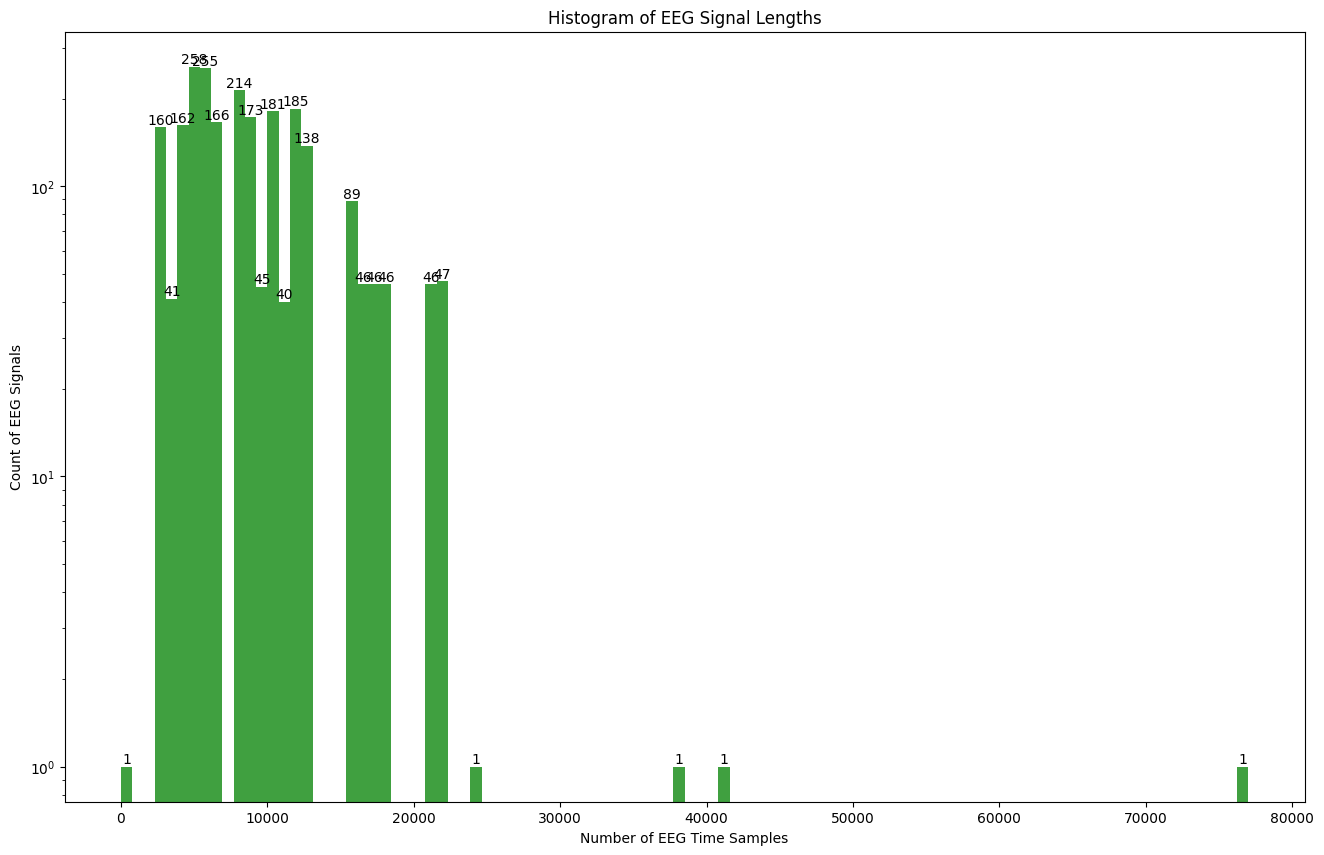

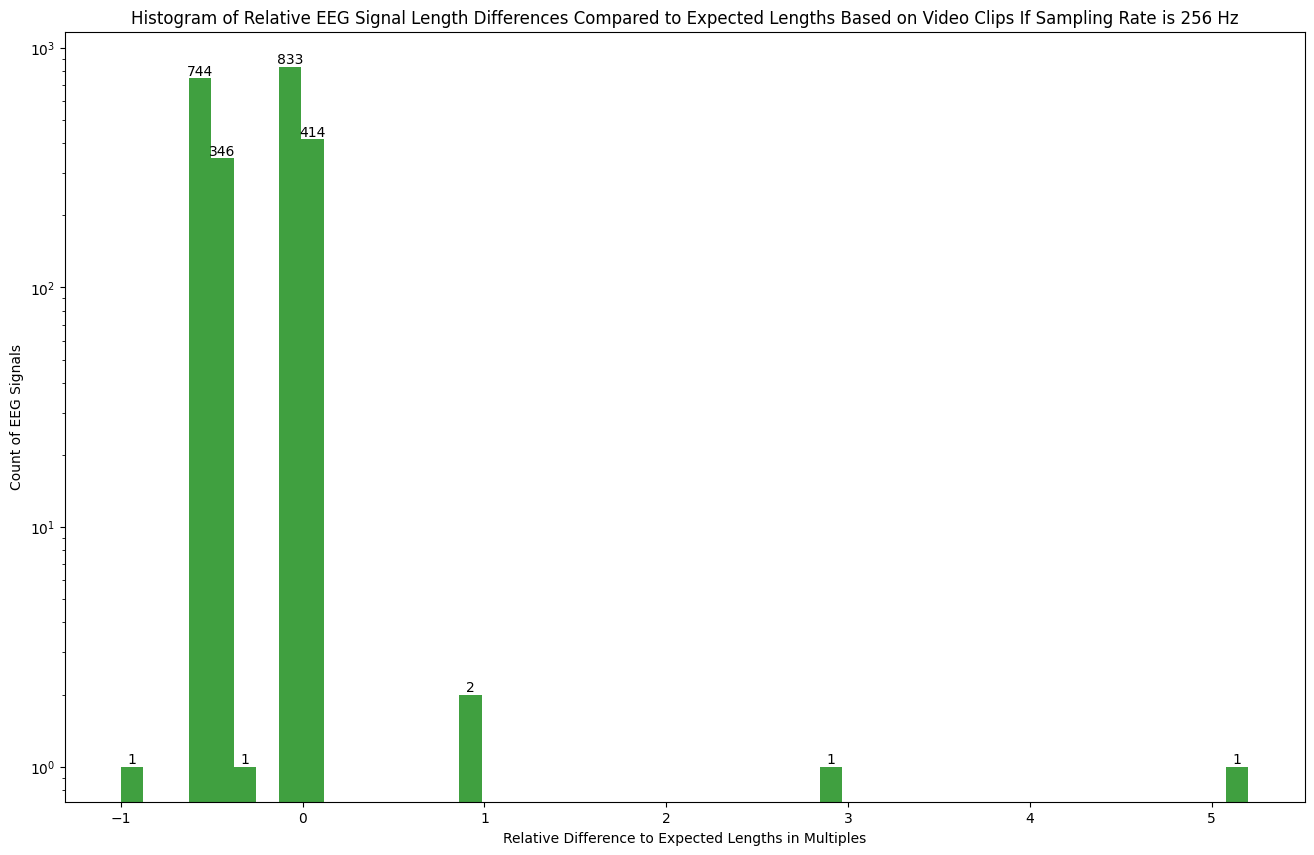

In [185]:
import matplotlib.pyplot as plt

signal_lengths_only = signal_metadata[:, 2]

plt.figure(figsize=(16, 10))
plt.title("Histogram of EEG Signal Lengths")
plt.ylabel("Count of EEG Signals")
plt.xlabel("Number of EEG Time Samples")
counts, bins, patches = plt.hist(signal_lengths_only, 100, facecolor='g', alpha=0.75, log=True)
plt.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge')

plt.figure(figsize=(16, 10))
plt.title("Histogram of Relative EEG Signal Length Differences Compared to Expected Lengths Based on Video Clips If Sampling Rate is 256 Hz")
plt.ylabel("Count of EEG Signals")
plt.xlabel("Relative Difference to Expected Lengths in Multiples")
counts, bins, patches = plt.hist(signal_metadata[:,4], 50, facecolor='g', alpha=0.75, log=True)
plt.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge');

About half of the signals are of the expected length if sampled at 256Hz, but around half are half the size, meaning that they probably have been sampled at half the sampling rate, 128Hz. We want to find out which signal should be removed as outliers while accounting for two possible sampling rates.

In [191]:
allowed_relative_difference = 0.05

Show the EEG signals that would be excluded by the allowed relative difference.

In [192]:
absolute_relative_difference = np.abs(signal_metadata[:,4])
signal_metadata[(absolute_relative_difference > allowed_relative_difference) & (np.abs(absolute_relative_difference - 0.5) > allowed_relative_difference)]

array([[ 2.00000000e+01,  0.00000000e+00,  2.45920000e+04,
         1.24160000e+04,  9.80670103e-01],
       [ 2.90000000e+01,  7.00000000e+00,  3.92500000e+03,
         9.02400000e+03, -5.65048759e-01],
       [ 3.20000000e+01,  0.00000000e+00,  7.69960000e+04,
         1.24160000e+04,  5.20135309e+00],
       [ 3.20000000e+01,  2.00000000e+00,  5.12200000e+03,
         7.04000000e+03, -2.72443182e-01],
       [ 3.20000000e+01,  8.00000000e+00,  3.83510000e+04,
         9.96266675e+03,  2.84947133e+00],
       [ 4.10000000e+01,  3.00000000e+00,  4.09550000e+04,
         2.15360000e+04,  9.01699480e-01],
       [ 5.10000000e+01,  2.00000000e+00,  1.00000000e+00,
         7.04000000e+03, -9.99857955e-01]])

Export the list of EEG signals to use without the outliers within the allowed relative difference.

In [195]:
import json

absolute_relative_difference = np.abs(signal_metadata[:,4])
usable_signals = signal_metadata[(absolute_relative_difference <= allowed_relative_difference) | (np.abs(absolute_relative_difference - 0.5) <= allowed_relative_difference)]

def should_subsample(rel_diff):
    abs_rel_diff = abs(rel_diff)
    return abs_rel_diff <= allowed_relative_difference or (abs_rel_diff - 0.5) <= allowed_relative_difference

usable_signals_list = [
    f"{participant_id}_{emotion_id}.0.txt"
    for participant_id, emotion_id, length, expected_length, relative_difference
    in usable_signals
]

with open("usable_signals.json", "w") as f:
    json.dump(usable_signals_list, f)